In [1]:
%autosave 60

Autosaving every 60 seconds


___
### еще больше интересного в моём __telegram канале__: https://t.me/ml_maxim
___

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
from io import StringIO
from scipy.optimize import minimize
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

____
Этот ноутбук про оценку данных парных оценок из домашнего задания студентов. Детали кода бота можно найти в репозитории. Результаты оценки и аналитика есть в канале

## подготовка данных

In [3]:
path_logs = 'logs'
users = os.listdir(path_logs)

In [4]:
dfs_list = []
for one_user in users:
    with open(f"{path_logs}/{one_user}/ratings.log", 'r', encoding='utf-8') as file:
        log_data = file.read()

    df_user = pd.read_csv(
        StringIO(log_data), header=None, 
        names=['timestamp', 'id', 'name_left', 'name_right', 'choice']
    )
    dfs_list.append(df_user)

In [5]:
df = pd.concat(dfs_list, axis=0).reset_index(drop=True)

df['choice'] = df['choice'].apply(lambda x: x.strip())
df['name_left'] = df['name_left'].apply(lambda x: x.strip())
df['name_right'] = df['name_right'].apply(lambda x: x.strip())

df = df[df['choice'] != 'SHOWN'].reset_index(drop=True)

In [6]:
df['choice'] = (
    df['choice']
    .apply(
        lambda x: 
        'left' if x == 'CHOSEN_LEFT' 
        else ('right' if x == 'CHOSEN_RIGHT' else 'error')
    )
)

In [7]:
# this code fix one of known bugs
df = df[df['name_left'].apply(lambda x: bool(x.strip()))].reset_index(drop=True)

In [8]:
# словарь нужен для далбнейшей аналитики
dict_image_mapping = dict(df[['name_left', 'id']].values)
dict_image_mapping.update(dict(df[['name_right', 'id']].values))

## код для проведения оценки

In [9]:
class CrowdBTRanker:
    """
    Image ranking system using the CrowdBT model for handling noisy pairwise comparison data.
    
    The CrowdBT model extends Bradley-Terry by accounting for inconsistent preferences,
    making it ideal for Tinder-like applications where user preferences may not be perfectly transitive.
    """
    
    def __init__(self, min_comparisons=5, prior_strength=0.1, convergence_threshold=1e-4):
        """
        Initialize the ranker with configuration parameters.
        
        Parameters:
        -----------
        min_comparisons : int
            Minimum number of comparisons required for an image to be included
        prior_strength : float
            Strength of the prior for smoothing (higher values = more smoothing)
        convergence_threshold : float
            Threshold for determining model convergence
        """
        self.min_comparisons = min_comparisons
        self.prior_strength = prior_strength
        self.convergence_threshold = convergence_threshold
        self.results = None
        
    def load_data(self, comparison_data):
        """
        Load and preprocess comparison data.
        
        Parameters:
        -----------
        comparison_data : list of tuples
            List of (left_image_id, right_image_id, choice) where choice is 'left' or 'right'
            
        Returns:
        --------
        self : CrowdBTRanker
            Returns self for method chaining
        """
        self.raw_data = comparison_data
        
        # Count comparisons per image
        image_counts = defaultdict(int)
        for left, right, choice in self.raw_data:
            image_counts[left] += 1
            image_counts[right] += 1
        
        # Filter images with sufficient comparisons
        self.valid_images = {img for img, count in image_counts.items() 
                           if count >= self.min_comparisons}
        
        # Filter comparisons to only include valid images
        self.filtered_data = []
        for left, right, choice in self.raw_data:
            if left in self.valid_images and right in self.valid_images:
                self.filtered_data.append((left, right, choice))
        
        # Report filtering results
        excluded_images = len(image_counts) - len(self.valid_images)
        if excluded_images > 0:
            warnings.warn(f"Excluded {excluded_images} images with fewer than {self.min_comparisons} comparisons")
            
        excluded_comparisons = len(self.raw_data) - len(self.filtered_data)
        if excluded_comparisons > 0:
            warnings.warn(f"Excluded {excluded_comparisons} comparisons involving filtered images")
        
        # Create image ID mapping
        self.images = sorted(list(self.valid_images))
        self.id_to_idx = {img: i for i, img in enumerate(self.images)}
        self.n_images = len(self.images)
        
        # Create comparison matrices
        self._create_comparison_matrices()
        
        # Check for intransitivity
        self.intransitivity_rate = self._analyze_intransitivity()
        print(f"Intransitivity rate: {self.intransitivity_rate:.2%}")
        if self.intransitivity_rate > 0.05:
            print("High intransitivity detected - CrowdBT model is recommended")
            
        return self
    
    def _create_comparison_matrices(self):
        """Create win and comparison count matrices with prior smoothing"""
        # Initialize matrices with prior for numerical stability
        prior = self.prior_strength
        self.win_matrix = np.full((self.n_images, self.n_images), prior)
        np.fill_diagonal(self.win_matrix, 0)
        
        self.count_matrix = np.full((self.n_images, self.n_images), 2*prior)
        np.fill_diagonal(self.count_matrix, 0)
        
        # Fill matrices with observed data
        for left, right, choice in self.filtered_data:
            i, j = self.id_to_idx[left], self.id_to_idx[right]
            self.count_matrix[i, j] += 1
            self.count_matrix[j, i] += 1
            
            if choice == 'left':
                self.win_matrix[i, j] += 1
            else:
                self.win_matrix[j, i] += 1
    
    def _analyze_intransitivity(self):
        """Measure intransitivity in the comparison data"""
        # Calculate empirical win probabilities
        with np.errstate(divide='ignore', invalid='ignore'):
            P = self.win_matrix / self.count_matrix
            
        n = self.n_images
        intransitive_triads = 0
        total_triads = 0
        
        # Check all possible triads of images
        for i in range(n):
            for j in range(i+1, n):
                for k in range(j+1, n):
                    # Skip if any pair has no comparisons
                    if (self.count_matrix[i,j] <= 2*self.prior_strength or 
                        self.count_matrix[j,k] <= 2*self.prior_strength or 
                        self.count_matrix[k,i] <= 2*self.prior_strength):
                        continue
                        
                    # Check for intransitivity: A>B, B>C, C>A
                    if (P[i,j] > 0.5 and P[j,k] > 0.5 and P[k,i] > 0.5) or \
                       (P[j,i] > 0.5 and P[k,j] > 0.5 and P[i,k] > 0.5):
                        intransitive_triads += 1
                    
                    total_triads += 1
        
        return intransitive_triads / max(1, total_triads)
    
    def fit(self, max_iterations=100):
        """
        Fit the CrowdBT model to the comparison data.
        
        Parameters:
        -----------
        max_iterations : int
            Maximum number of iterations for the EM algorithm
            
        Returns:
        --------
        self : CrowdBTRanker
            Returns self for method chaining
        """
        if not hasattr(self, 'filtered_data'):
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Initialize parameters
        scores = np.ones(self.n_images) / self.n_images
        worker_reliability = 0.9  # Initial reliability estimate
        
        # Run EM algorithm
        for iter in range(max_iterations):
            # E-step: estimate reliability for each comparison
            reliabilities = []
            for left, right, choice in self.filtered_data:
                i, j = self.id_to_idx[left], self.id_to_idx[right]
                p_ij = scores[i] / (scores[i] + scores[j])
                
                # Probability that worker is reliable given the observed choice
                if choice == 'left':
                    r = (worker_reliability * p_ij) / \
                        (worker_reliability * p_ij + (1-worker_reliability) * (1-p_ij))
                else:  # choice == 'right'
                    r = (worker_reliability * (1-p_ij)) / \
                        (worker_reliability * (1-p_ij) + (1-worker_reliability) * p_ij)
                
                reliabilities.append(r)
            
            # M-step: update scores
            new_scores = np.ones(self.n_images) * self.prior_strength  # Small prior
            
            for idx, (left, right, choice) in enumerate(self.filtered_data):
                i, j = self.id_to_idx[left], self.id_to_idx[right]
                r = reliabilities[idx]
                
                if choice == 'left':
                    new_scores[i] += r
                    new_scores[j] += (1-r)
                else:  # choice == 'right'
                    new_scores[i] += (1-r)
                    new_scores[j] += r
            
            # Normalize scores
            new_scores = new_scores / np.sum(new_scores)
            
            # Update worker reliability
            new_reliability = np.mean(reliabilities)
            
            # Check for convergence
            if iter > 0:
                score_change = np.max(np.abs(new_scores - scores))
                reliability_change = abs(new_reliability - worker_reliability)
                
                if score_change < self.convergence_threshold and reliability_change < self.convergence_threshold:
                    print(f"Converged after {iter+1} iterations")
                    break
            
            # Update parameters for next iteration
            scores = new_scores
            worker_reliability = new_reliability
            
            if iter == max_iterations - 1:
                warnings.warn(f"Maximum iterations ({max_iterations}) reached without convergence")
        
        # Store results
        self.scores = scores
        self.worker_reliability = worker_reliability
        
        # Create results dataframe
        self.results = pd.DataFrame({
            'image_id': self.images,
            'score': self.scores,
            'rank': (-self.scores).argsort().argsort() + 1
        }).sort_values('rank')
        
        # Evaluate model fit
        self._evaluate_model_fit()
        
        return self
    
    def _evaluate_model_fit(self):
        """Evaluate how well the model fits the data"""
        # Calculate expected win probabilities
        expected_probs = np.zeros((self.n_images, self.n_images))
        for i in range(self.n_images):
            for j in range(self.n_images):
                if i != j:
                    expected_probs[i,j] = self.scores[i] / (self.scores[i] + self.scores[j])
        
        # Calculate expected wins
        expected_wins = expected_probs * self.count_matrix
        
        # Calculate residuals
        with np.errstate(divide='ignore', invalid='ignore'):
            residuals = (self.win_matrix - expected_wins) / np.sqrt(expected_wins)
        
        # Mask diagonal and zero-comparison cells
        mask = (self.count_matrix > 2*self.prior_strength) & ~np.eye(self.n_images, dtype=bool)
        valid_residuals = residuals[mask]
        
        # Store fit statistics
        self.max_residual = np.max(np.abs(valid_residuals))
        self.mean_residual = np.mean(np.abs(valid_residuals))
        
        print(f"Model fit: max residual = {self.max_residual:.2f}, mean residual = {self.mean_residual:.2f}")
        print(f"Worker reliability: {self.worker_reliability:.2f}")
        
        # Find problematic comparisons
        threshold = 2.0  # Residual threshold for flagging
        problem_indices = np.where((np.abs(residuals) > threshold) & mask)
        
        if len(problem_indices[0]) > 0:
            print(f"Found {len(problem_indices[0])} problematic comparisons (residual > {threshold})")
            
            # Store problematic comparisons
            self.problematic_comparisons = []
            for i, j in zip(problem_indices[0], problem_indices[1]):
                self.problematic_comparisons.append({
                    'image1': self.images[i],
                    'image2': self.images[j],
                    'observed_wins': self.win_matrix[i,j],
                    'total_comparisons': self.count_matrix[i,j],
                    'expected_wins': expected_wins[i,j],
                    'residual': residuals[i,j]
                })
    
    def get_rankings(self):
        """
        Get the final image rankings.
        
        Returns:
        --------
        pd.DataFrame
            DataFrame with image_id, score, and rank columns
        """
        if self.results is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        return self.results
    
    def get_top_images(self, n=10):
        """
        Get the top-ranked images.
        
        Parameters:
        -----------
        n : int
            Number of top images to return
            
        Returns:
        --------
        pd.DataFrame
            DataFrame with the top n ranked images
        """
        if self.results is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        return self.results.head(n)
    
    def get_problematic_images(self):
        """
        Get images involved in problematic comparisons.
        
        Returns:
        --------
        pd.DataFrame
            DataFrame with problematic images and their frequency in problematic comparisons
        """
        if not hasattr(self, 'problematic_comparisons'):
            return pd.DataFrame(columns=['image_id', 'problem_count'])
        
        # Count problematic comparisons per image
        problem_counts = defaultdict(int)
        for comp in self.problematic_comparisons:
            problem_counts[comp['image1']] += 1
            problem_counts[comp['image2']] += 1
        
        # Create dataframe
        problem_df = pd.DataFrame({
            'image_id': list(problem_counts.keys()),
            'problem_count': list(problem_counts.values())
        }).sort_values('problem_count', ascending=False)
        
        return problem_df
    
    def visualize_results(self, output_dir='.', top_n=20):
        """
        Create visualizations of the ranking results.
        
        Parameters:
        -----------
        output_dir : str
            Directory to save visualization files
        top_n : int
            Number of top images to include in visualizations
            
        Returns:
        --------
        None
        """
        if self.results is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Plot 1: Top N images by score
        plt.figure(figsize=(12, 8))
        top_images = self.results.head(top_n)
        plt.barh(top_images['image_id'], top_images['score'], color='skyblue')
        plt.xlabel('CrowdBT Score')
        plt.title(f'Top {top_n} Images by CrowdBT Score')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'top_images.png'))
        plt.close()
        
        # Plot 2: Score distribution
        plt.figure(figsize=(10, 6))
        plt.hist(self.results['score'], bins=20, color='skyblue', edgecolor='black')
        plt.xlabel('CrowdBT Score')
        plt.ylabel('Number of Images')
        plt.title('Distribution of Image Scores')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'score_distribution.png'))
        plt.close()
        
        # Plot 3: Problematic images
        problem_df = self.get_problematic_images()
        if len(problem_df) > 0:
            plt.figure(figsize=(12, 8))
            top_problems = problem_df.head(min(top_n, len(problem_df)))
            plt.barh(top_problems['image_id'], top_problems['problem_count'], color='salmon')
            plt.xlabel('Number of Problematic Comparisons')
            plt.title('Images with Most Problematic Comparisons')
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, 'problematic_images.png'))
            plt.close()
        
        print(f"Visualizations saved to {output_dir}")
    
    def export_results(self, filepath):
        """
        Export ranking results to CSV.
        
        Parameters:
        -----------
        filepath : str
            Path to save the CSV file
            
        Returns:
        --------
        None
        """
        if self.results is None:
            raise ValueError("Model not fitted. Call fit() first.")
        
        self.results.to_csv(filepath, index=False)
        print(f"Results exported to {filepath}")


# Example usage
def rank_images(comparison_data, min_comparisons=5, output_dir='results'):
    """
    Convenience function to rank images from comparison data.
    
    Parameters:
    -----------
    comparison_data : list of tuples
        List of (left_image_id, right_image_id, choice) where choice is 'left' or 'right'
    min_comparisons : int
        Minimum number of comparisons required for an image
    output_dir : str
        Directory to save results and visualizations
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with the ranking results
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize and run ranker
    ranker = CrowdBTRanker(min_comparisons=min_comparisons)
    ranker.load_data(comparison_data)
    ranker.fit()
    
    # Generate outputs
    ranker.visualize_results(output_dir=output_dir)
    ranker.export_results(os.path.join(output_dir, 'image_rankings.csv'))
    
    return ranker.get_rankings()

# проведение оценки 

In [10]:
rankings = rank_images(
    df[['name_left', 'name_right', 'choice']].values, 
    min_comparisons=2
)

Intransitivity rate: 13.08%
High intransitivity detected - CrowdBT model is recommended
Converged after 42 iterations
Model fit: max residual = 3.18, mean residual = 0.56
Worker reliability: 1.00
Found 3 problematic comparisons (residual > 2.0)
Visualizations saved to results
Results exported to results/image_rankings.csv


## Выводы
#### Уровень интранзитивности: 13.08%

Это показывает, что 13.08% всех возможных триад изображений в вашем наборе данных демонстрируют интранзитивные предпочтения (А > Б, Б > В, но В > А).

Уровень выше 5% считается высоким и указывает на значительную непоследовательность в предпочтениях пользователей.

Такой высокий показатель оправдывает использование модели CrowdBT, которая лучше справляется с подобными несоответствиями, чем традиционные методы.

#### Сходимость после 42 итераций

Алгоритм CrowdBT достиг стабильного решения после 42 итераций.

Это хороший знак, показывающий, что модель нашла согласованное ранжирование, несмотря на противоречия в данных.

#### Качество модели: максимальный остаток = 3.18, средний остаток = 0.56

Остатки (residuals) измеряют разницу между наблюдаемыми и ожидаемыми результатами для каждого сравнения.

Максимальный остаток 3.18 говорит о том, что есть некоторые сравнения, которые модель затрудняется предсказать точно.

Средний остаток 0.56 указывает на то, что в среднем предсказания модели достаточно близки к наблюдаемым данным, но всё же остается некоторая необъясненная вариация.

#### Надежность оценок: 1.00

Это предполагает, что модель оценивает сравнения как высоконадежные.

Значение 1.00 является максимально возможным и указывает на то, что модель считает все сравнения согласованными с итоговым ранжированием.

Это может показаться противоречащим высокому уровню интранзитивности, но это говорит о том, что модель нашла ранжирование, которое наилучшим образом согласует наблюдаемые предпочтения.

#### Обнаружено 3 проблемных сравнения (остаток > 2.0)

Модель выявила 3 конкретных сравнения, где её предсказания значительно отличаются от наблюдаемых результатов.

Это сравнения, где остаток превышает 2.0, что считается высоким порогом.

Эти проблемные сравнения могут представлять собой выбросы, очень непоследовательные предпочтения или потенциальные ошибки в сборе данных.

# optional: оцениваем графики мультимодальной Gemma 3
(локальная gemma3:12b, запущенная в ollama)

In [11]:
top_n_images = 16

In [12]:
# искали топ 10 уникальных имен
rankings.head(top_n_images)['image_id'].apply(lambda x: '_'.join(x.split('_')[: 2])).nunique()

10

In [13]:
top_images = rankings.head(top_n_images)['image_id'].values

## используем ollama и gemma 3, чтобы получить рецепт лучшего EDA графика

In [127]:
import os
import io
import base64
from tqdm import tqdm
from PIL import Image
import requests
from IPython.display import display

In [16]:
def verify_and_encode_image(image_path):
    """
    Verify image integrity and encode it properly for Ollama
    
    Args:
        image_path: Path to the image file
        
    Returns:
        Properly encoded image or None if the image is corrupted
    """
    try:
        # First verify the image integrity
        img = Image.open(image_path)
        img.verify()  # Verify image file integrity
        
        # Reopen the image (necessary after verify)
        img = Image.open(image_path)
        
        # Convert and resize for Gemma 3
        img = img.convert('RGB')
        img = img.resize((896, 896))
        
        # Save to a new buffer with proper format
        buffered = io.BytesIO()
        img.save(buffered, format="PNG")  # Using PNG instead of JPEG
        
        # Get base64 encoding
        img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
        return f"data:image/png;base64,{img_str}"
    
    except (IOError, SyntaxError) as e:
        print(f"Image verification failed: {e}")
        return None

def get_multimodal_response(text, image_path, system_text='отвечай коротко', model="gemma3:12b"):
    """
    Get response from model using both text and image with robust error handling
    
    Args:
        text: Text prompt
        image_path: Path to image
        system_text: System prompt
        model: Model name
    
    Returns:
        Model response or error message
    """
    # Check if file exists
    if not os.path.exists(image_path):
        return f"Error: File '{image_path}' not found"
    
    # Verify and encode the image
    encoded_image = verify_and_encode_image(image_path)
    base64_part = encoded_image.split(',')[1]
    if not encoded_image:
        return "Error: Image verification failed. The image may be corrupted."
    
    url_completions = "http://localhost:11434/api/chat"
    headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer none",
        "X-ASGK-TOKEN": 'a',
    }
    
    data = {
        "model": model,
        "messages": [
            {
                "role": "system",
                "content": system_text
            },
            {
                "role": "user",
                "content": text,
                "images": [base64_part]
            }
        ],
        "stream": False,
        "temperature": 1,
    }
    
    try:
        response = requests.post(url_completions, headers=headers, json=data)
        
        if response.status_code != 200:
            return f"Error: {response.status_code}\n{response.text}"
        
        return response.json()['message']['content']
    
    except Exception as e:
        return f"Request error: {str(e)}"

In [17]:
system_prompt = """
Перед тобой высоко оцененный график по мнению многих людей. 
Попробуй выделить 5 причин, почему он так высоко оценен.
Дай output глубокую оценку 5 пунктов почему этот график такой хороший, понятный, полезный.
Дай для каждого пункта не более двух предложений. 
"""

prompt = """
Почему этот график - хороший пример EDA визуализации данных? 
Напиши ответ в пяти пунктах его ключевые особенности и преимущества.
"""

In [106]:
llm_estimation_report = []

for one_image in tqdm(top_images):
    response = get_multimodal_response(prompt, f'images/{dict_image_mapping.get(one_image)}/{one_image}')
    llm_estimation_report.append(response)

100%|██████████| 16/16 [10:05<00:00, 37.86s/it]


### делаем word cloud

In [117]:
# %pip install -q pymystem3 wordcloud matplotlib nltk pymorphy2

In [118]:
# import nltk
# nltk.download('stopwords')

In [120]:
from pymystem3 import Mystem
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import pymorphy2
import re

In [121]:
# Инициализация Mystem для лемматизации
mystem = Mystem()
morph = pymorphy2.MorphAnalyzer()

# Получение стоп-слов для русского языка
russian_stopwords = set(stopwords.words('russian'))

In [122]:
additional_stopwords = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так',
    'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было',
    'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг',
    'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж',
    'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть',
    'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего',
    'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого',
    'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас',
    'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть',
    'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много',
    'разве', 'три', 'эту', 'моя', 'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше',
    'чуть', 'том', 'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между'
}

# Объединяем все стоп-слова
all_stopwords = russian_stopwords.union(additional_stopwords)

# Функция для предобработки текста
def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Удаление чисел, знаков препинания и прочих символов
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    
    # Токенизация и лемматизация
    tokens = text.split()
    lemmatized_tokens = []
    
    for token in tokens:
        # Лемматизация с помощью pymorphy2
        parsed_token = morph.parse(token)[0]
        lemma = parsed_token.normal_form
        
        # Проверка, является ли слово стоп-словом или служебной частью речи
        if (lemma not in all_stopwords and 
            parsed_token.tag.POS not in ('PREP', 'CONJ', 'PRCL', 'NPRO')):
            lemmatized_tokens.append(lemma)
    
    return ' '.join(lemmatized_tokens)

In [123]:
# Предобработка всех текстов
preprocessed_texts = [preprocess_text(text) for text in llm_estimation_report]
preprocessed_text = ' '.join(preprocessed_texts)

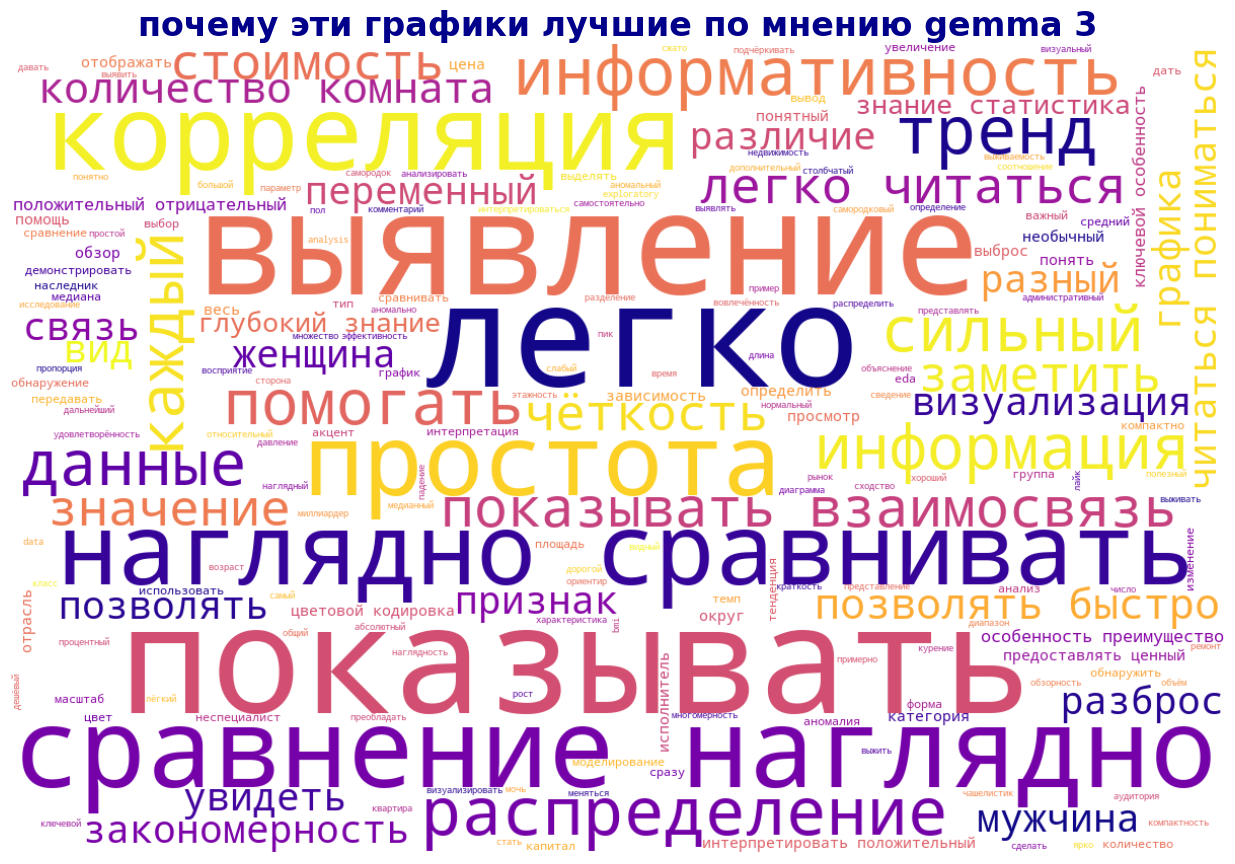

In [126]:
# Создание более красивого облака слов с улучшенными цветами
wordcloud = WordCloud(
    width=1200, 
    height=800, 
    background_color='white',
    max_font_size=150,
    colormap='plasma',  # Более яркая цветовая схема
    prefer_horizontal=0.9,  # Больше горизонтальных слов
    random_state=12,
    font_path=None,  # Укажите путь к шрифту с поддержкой кириллицы, если нужно
    contour_width=1,
    contour_color='steelblue',
    relative_scaling=0.5  # Лучший баланс между частотой и размером шрифта
).generate(preprocessed_text)

# Создание фигуры с высоким разрешением
plt.figure(figsize=(16, 9), dpi=100)  # Высокое разрешение
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("почему эти графики лучшие по мнению gemma 3", fontsize=24, fontweight='bold', color='darkblue')
plt.tight_layout(pad=2)

# Сохранение изображения в высоком разрешении
plt.savefig('wordcloud_high_res.png', dpi=100, bbox_inches='tight')

# Отображение результата
plt.show()

### делаем pdf отчет

In [119]:
# %pip install -q pymupdf-fonts

In [112]:
# %pip install -q markdown

In [113]:
import pymupdf
import markdown
from bs4 import BeautifulSoup
import re

In [134]:
def create_pdf_with_pymupdf_simple(image_paths, texts, output_pdf_path):
    """
    Создание PDF с изображениями и текстом с корректным размещением на странице
    """
    doc = pymupdf.open()
    
    for img_path, text in zip(image_paths, texts):
        page = doc.new_page()
        
        # Получаем шрифт с поддержкой кириллицы
        font = pymupdf.Font("cjk")
        small_font = pymupdf.Font("cjk")  # Для подписи автора
        
        # Внедряем шрифт в документ
        page.insert_font(fontname="myfont", fontbuffer=font.buffer)
        page.insert_font(fontname="smallfont", fontbuffer=small_font.buffer)
        
        # Вставляем изображение
        img_rect = pymupdf.Rect(72, 72, page.rect.width - 72, page.rect.height / 2)
        page.insert_image(img_rect, filename=img_path)
        
        # Добавляем подпись автора (путь к изображению) под изображением
        author_y = img_rect.y1 + 15  # Позиция для подписи автора
        
        # Получаем только имя файла из полного пути
        file_name = os.path.basename(img_path)

        # Начальная позиция для основного текста (после подписи автора)
        text_y = author_y + 25
        left_margin = 72
        right_margin = page.rect.width - 72
        text_width = right_margin - left_margin
        line_height = 15  # Высота строки
        
        # Добавляем подпись автора
        # shape = page.new_shape()
        # shape.insert_text(
        #     (left_margin, author_y),
        #     f"Автор: {file_name}",
        #     fontname="smallfont",
        #     fontsize=10
        # )
        # shape.commit()
        
        # Разбиваем текст на пункты
        points = re.split(r'\d+\.\s+', text)[1:]  # Пропускаем пустой элемент в начале
        
        for point in points:
            # Удаляем символы ** из текста
            point = point.replace('*', '')
            
            # Разбиваем пункт на заголовок и описание
            parts = point.split(':', 1)
            title = parts[0].strip()
            description = parts[1].strip() if len(parts) > 1 else ""
            
            # Добавляем заголовок
            shape = page.new_shape()
            shape.insert_text(
                (left_margin, text_y),
                title + ":",
                fontname="myfont",
                fontsize=12
            )
                    
            shape.commit()
            text_y += line_height
            
            # Разбиваем описание на строки
            words = description.split()
            lines = []
            current_line = []
            
            for word in words:
                test_line = ' '.join(current_line + [word])
                text_width_px = 12 * len(test_line) * 0.5  # Примерная оценка ширины
                
                if text_width_px <= text_width:
                    current_line.append(word)
                else:
                    if current_line:
                        lines.append(' '.join(current_line))
                    current_line = [word]
            
            if current_line:
                lines.append(' '.join(current_line))
            
            # Добавляем описание
            for line in lines:
                # Проверяем, достаточно ли места на странице
                if text_y + line_height > page.rect.height - 72:
                    page = doc.new_page()
                    page.insert_font(fontname="myfont", fontbuffer=font.buffer)
                    page.insert_font(fontname="smallfont", fontbuffer=small_font.buffer)
                    text_y = 72  # Сбрасываем позицию текста
                
                shape = page.new_shape()
                shape.insert_text(
                    (left_margin + 20, text_y),  # Небольшой отступ для описания
                    line,
                    fontname="myfont",
                    fontsize=12
                )
                shape.commit()
                text_y += line_height
            
            # Добавляем отступ между пунктами
            text_y += 10
    
    # Оптимизируем и сохраняем
    doc.subset_fonts()
    doc.ez_save(output_pdf_path)
    print(f"PDF успешно создан: {output_pdf_path}")


In [135]:
images_path_list = [f'images/{dict_image_mapping.get(one_image)}/{one_image}' for one_image in top_images]

create_pdf_with_pymupdf_simple(
    images_path_list,
    llm_estimation_report,
    'pdf_report_with_names.pdf'
)

PDF успешно создан: pdf_report_with_names.pdf


In [116]:
print('well done')

well done
